# Линейная регрессия на реальных данных (привет Малые Кармакулы)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

### Считываем уже обработанные на прошлом занятии данные 

In [2]:
df = pd.read_csv('EDA_demo_data/karmakuly_processed.csv', parse_dates=['Date'], index_col='Date')
df.head()

,tcc,lcc,wdir,wvel,wgust,prec,tg,ta,rh,td,ps,psl
Date,,,,,,,,,,,,
1966-12-31 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1966-12-31 21:00:00,10.0,10.0,180.0,12.0,NaN,NaN,NaN,-7.3,97.0,-8.0,1012.7,1014.8
1967-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-01-01 03:00:00,10.0,10.0,180.0,9.0,NaN,0.0,NaN,-7.6,90.0,-9.0,1010.2,1012.3
1967-01-01 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Разделяем целевой признак (целевую переменную) от остальных, обучаем модель 

In [13]:
target = 'ta'

df_Xy = df.copy().drop(columns=['tg', 'td', 'psl']).dropna()

y = df_Xy[target]
X = df_Xy.drop(target, axis=1)

model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [8]:
X

,tcc,lcc,wdir,wvel,wgust,prec,rh,td,ps,psl
Date,,,,,,,,,,
1976-11-30 18:00:00,3.0,0.0,110.0,27.0,30.0,0.0,88.0,-23.8,1003.7,1005.8
1976-11-30 21:00:00,2.0,0.0,120.0,25.0,28.0,0.0,85.0,-24.6,1003.4,1005.5
1976-12-01 00:00:00,0.0,0.0,110.0,23.0,28.0,0.0,85.0,-24.8,1003.6,1005.7
1976-12-01 03:00:00,0.0,0.0,100.0,26.0,30.0,0.0,86.0,-25.1,1002.8,1004.9
1976-12-01 06:00:00,3.0,0.0,110.0,27.0,31.0,0.0,85.0,-25.1,1002.3,1004.4
...,...,...,...,...,...,...,...,...,...,...
2022-07-31 03:00:00,5.0,0.0,190.0,2.0,4.0,0.0,83.0,8.9,1023.5,1025.4
2022-07-31 06:00:00,6.0,0.0,360.0,1.0,2.0,0.0,79.0,9.4,1023.0,1024.9
2022-07-31 09:00:00,8.0,0.0,350.0,2.0,4.0,0.0,67.0,8.6,1022.6,1024.5


### Применяем модель (пока что к тем же данным, на которых она обучалась)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


corr coeff is  0.48693720615953806
corr coeff^2 is  0.23710784274245647
R2 is  0.23710784274245633
RMSE is  8.40644888360408


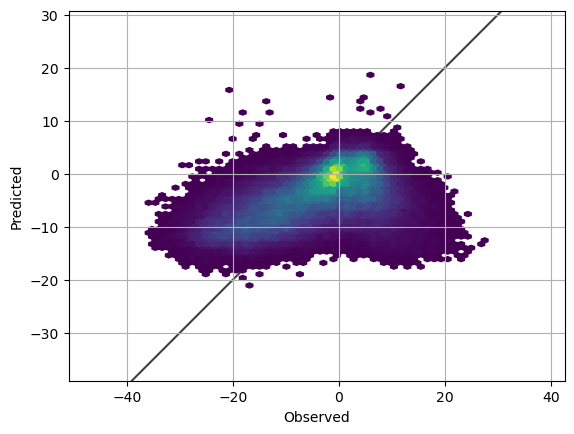

In [14]:
y_pred = model.predict(X)

plt.figure()
#plt.scatter(y, y_pred)
plt.hexbin (y, y_pred, mincnt=1, gridsize=50)

plt.axis('equal')
ax = plt.gca()
lims = [
       np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
       np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
       ]
plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
plt.xlim(lims)
plt.ylim(lims)
plt.grid()
plt.xlabel('Observed')
plt.ylabel('Predicted')

r = np.corrcoef(y_pred, y)[0,1]
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print ('corr coeff is ', r)
print ('corr coeff^2 is ', r**2)

print ('R2 is ', r2)
print ('RMSE is ', np.sqrt (mse))


### Посмотрим на коэффициенты регрессии

,coef
tcc,0.622332
lcc,0.151602
wdir,0.018836
wvel,-0.291179
wgust,0.068843
prec,0.099627
rh,0.104323
ps,0.044237


Text(0.5, 1.0, 'Коэффициенты линейной регрессии')

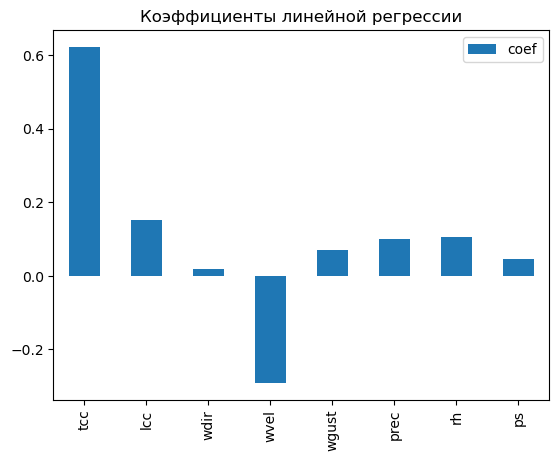

In [15]:
coefs = pd.DataFrame(model.coef_, X.columns, columns=['coef']) 
display(coefs)
coefs.plot.bar()
plt.title('Коэффициенты линейной регрессии')


### Попробуем теперь логистическую регрессию

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

df_Xy = df.copy().drop(columns=['tg', 'td', 'psl']).dropna()

y = df_Xy['tcc'] == 0 #overcast or clear

X = df_Xy.drop(columns=['tcc'])




In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [22]:
y_predicted = model.predict(X)

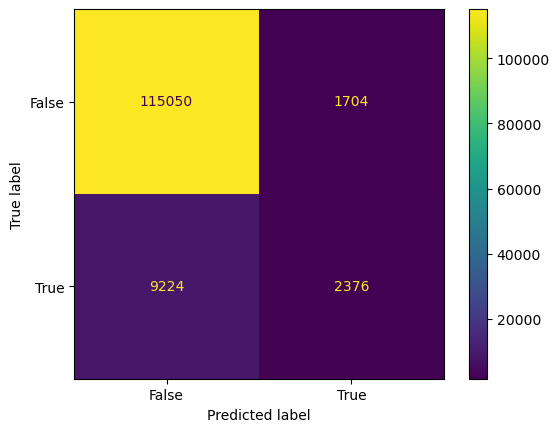

In [23]:
_ = ConfusionMatrixDisplay.from_estimator(model, X, y)